# 05 Final Results

**Project:** Interpretable vs Black-Box Models for Predicting Death Events in Heart Failure Patients

This notebook is where I combine the model results into one final comparison table for the paper. It is meant to be run after:

1. `02_preprocessing.ipynb`
2. `03_models.ipynb`
3. `04_interpretability.ipynb`

For my part, I am combining my Logistic Regression and Random Forest results. Tala can add her Decision Tree and Gradient Boosting results in the same format.


## What this notebook should produce

This notebook saves the final files that can be used in the README and the NeurIPS paper:

- `results/metrics/final_model_comparison.csv`
- `results/tables/final_results_table.csv`
- `results/tables/time_feature_comparison.csv`
- `results/tables/final_interpretability_summary.csv`
- final comparison figures in `results/figures/`

The most important table is the final model comparison table, because that is what answers the main project question.


In [1]:
# Imports and setup

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [2]:
# This lets the notebook work whether I run it from the main project folder or from the notebooks folder.

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

for folder in [RESULTS_DIR, TABLES_DIR, METRICS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tables folder:", TABLES_DIR)
print("Metrics folder:", METRICS_DIR)
print("Figures folder:", FIGURES_DIR)


Project root: c:\Users\salem\Desktop\CS439\CS439-Project
Tables folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables
Metrics folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\metrics
Figures folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures


## Helper functions

I am using helper functions here so the final notebook does not break if Tala's metrics file is not added yet. If a file is missing, the notebook creates a clear placeholder row instead of crashing.


In [3]:
def find_existing_file(possible_paths):
    """Return the first existing file from a list of possible paths."""
    for path in possible_paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def standardize_metrics_table(df: pd.DataFrame, owner: str) -> pd.DataFrame:
    """Standardize column names and keep only the columns needed for the final comparison."""
    df = df.copy()

    # Make column names easier to match.
    rename_map = {}
    for col in df.columns:
        clean = col.strip().lower().replace(" ", "_").replace("-", "_")
        if clean in ["model", "model_name"]:
            rename_map[col] = "model"
        elif clean in ["time_version", "time_feature", "time", "with_time"]:
            rename_map[col] = "time_version"
        elif clean in ["accuracy", "acc"]:
            rename_map[col] = "accuracy"
        elif clean in ["precision"]:
            rename_map[col] = "precision"
        elif clean in ["recall", "sensitivity"]:
            rename_map[col] = "recall"
        elif clean in ["f1", "f1_score"]:
            rename_map[col] = "f1"
        elif clean in ["roc_auc", "auc", "roc_auc_score"]:
            rename_map[col] = "roc_auc"

    df = df.rename(columns=rename_map)

    needed_cols = ["model", "time_version", "accuracy", "precision", "recall", "f1", "roc_auc"]
    for col in needed_cols:
        if col not in df.columns:
            df[col] = np.nan

    df = df[needed_cols]
    df["owner"] = owner

    # Keep the time version wording consistent.
    df["time_version"] = (
        df["time_version"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .replace({
            "with": "with_time",
            "without": "without_time",
            "yes": "with_time",
            "no": "without_time",
            "true": "with_time",
            "false": "without_time",
            "nan": np.nan,
        })
    )

    # Convert metric columns to numbers.
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def make_placeholder_metrics(owner: str, models):
    """Create blank rows so the final table keeps the expected project structure."""
    rows = []
    for model in models:
        for time_version in ["with_time", "without_time"]:
            rows.append({
                "model": model,
                "time_version": time_version,
                "accuracy": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "roc_auc": np.nan,
                "owner": owner,
            })
    return pd.DataFrame(rows)


def load_metrics_file(possible_file_names, owner: str, placeholder_models):
    """Load one metrics file if it exists. Otherwise, return placeholder rows."""
    possible_paths = []
    for name in possible_file_names:
        possible_paths.append(METRICS_DIR / name)
        possible_paths.append(TABLES_DIR / name)
        possible_paths.append(PROJECT_ROOT / name)

    found_path = find_existing_file(possible_paths)

    if found_path is None:
        print(f"No metrics file found yet for {owner}. I am using placeholder rows for now.")
        return make_placeholder_metrics(owner, placeholder_models)

    print(f"Loaded {owner} metrics from: {found_path}")
    loaded = pd.read_csv(found_path)
    return standardize_metrics_table(loaded, owner)


## Load Salem and Tala metrics

Salem's file should come from `03_models.ipynb`:

`results/metrics/salem_logistic_randomforest_metrics.csv`

Tala can save her file using one of these names:

- `tala_tree_boosting_metrics.csv`
- `groupmember_tree_boosting_metrics.csv`
- `tala_decisiontree_gradientboosting_metrics.csv`

If Tala's file is not ready yet, this notebook still runs and shows blank rows for her models.


In [4]:
salem_metrics = load_metrics_file(
    possible_file_names=[
        "salem_logistic_randomforest_metrics.csv",
        "salem_metrics.csv",
        "logistic_randomforest_metrics.csv",
    ],
    owner="Salem",
    placeholder_models=["Logistic Regression", "Random Forest"],
)

print("\nSalem metrics:")
display(salem_metrics)


Loaded Salem metrics from: c:\Users\salem\Desktop\CS439\CS439-Project\results\metrics\salem_logistic_randomforest_metrics.csv

Salem metrics:


,model,time_version,accuracy,precision,recall,f1,roc_auc,owner
0,Logistic Regression,with_time,0.800000,0.733333,0.578947,0.647059,0.857510,Salem
1,Logistic Regression,without_time,0.700000,0.526316,0.526316,0.526316,0.740693,Salem
2,Random Forest,with_time,0.833333,0.846154,0.578947,0.687500,0.899230,Salem
3,Random Forest,without_time,0.733333,0.615385,0.421053,0.500000,0.796534,Salem


In [5]:
tala_metrics = load_metrics_file(
    possible_file_names=[
        "tala_tree_boosting_metrics.csv",
        "groupmember_tree_boosting_metrics.csv",
        "tala_decisiontree_gradientboosting_metrics.csv",
        "decisiontree_gradientboosting_metrics.csv",
    ],
    owner="Tala",
    placeholder_models=["Decision Tree", "Gradient Boosting"],
)

print("\nTala metrics:")
display(tala_metrics)


No metrics file found yet for Tala. I am using placeholder rows for now.

Tala metrics:


,model,time_version,accuracy,precision,recall,f1,roc_auc,owner
0,Decision Tree,with_time,NaN,NaN,NaN,NaN,NaN,Tala
1,Decision Tree,without_time,NaN,NaN,NaN,NaN,NaN,Tala
2,Gradient Boosting,with_time,NaN,NaN,NaN,NaN,NaN,Tala
3,Gradient Boosting,without_time,NaN,NaN,NaN,NaN,NaN,Tala


## Final model comparison table

This is the main results table for the project. It should eventually have 8 rows:

1. Logistic Regression with time
2. Logistic Regression without time
3. Random Forest with time
4. Random Forest without time
5. Decision Tree with time
6. Decision Tree without time
7. Gradient Boosting with time
8. Gradient Boosting without time


In [6]:
final_results = pd.concat([salem_metrics, tala_metrics], ignore_index=True)

# Keep the order clean for the final project.
model_order = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]
time_order = ["with_time", "without_time"]

final_results["model"] = final_results["model"].astype(str).str.strip()
final_results["model_order"] = final_results["model"].apply(lambda x: model_order.index(x) if x in model_order else 99)
final_results["time_order"] = final_results["time_version"].apply(lambda x: time_order.index(x) if x in time_order else 99)

final_results = (
    final_results
    .sort_values(["model_order", "time_order", "owner"])
    .drop(columns=["model_order", "time_order"])
    .reset_index(drop=True)
)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Rounded copy for easier reading.
final_results_display = final_results.copy()
for col in metric_cols:
    final_results_display[col] = final_results_display[col].round(4)

final_model_path = METRICS_DIR / "final_model_comparison.csv"
final_table_path = TABLES_DIR / "final_results_table.csv"

final_results.to_csv(final_model_path, index=False)
final_results.to_csv(final_table_path, index=False)

print("Saved final model comparison to:", final_model_path)
print("Saved final results table to:", final_table_path)

display(final_results_display)


Saved final model comparison to: c:\Users\salem\Desktop\CS439\CS439-Project\results\metrics\final_model_comparison.csv
Saved final results table to: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\final_results_table.csv


,model,time_version,accuracy,precision,recall,f1,roc_auc,owner
0,Logistic Regression,with_time,0.8000,0.7333,0.5789,0.6471,0.8575,Salem
1,Logistic Regression,without_time,0.7000,0.5263,0.5263,0.5263,0.7407,Salem
2,Decision Tree,with_time,NaN,NaN,NaN,NaN,NaN,Tala
3,Decision Tree,without_time,NaN,NaN,NaN,NaN,NaN,Tala
4,Random Forest,with_time,0.8333,0.8462,0.5789,0.6875,0.8992,Salem
5,Random Forest,without_time,0.7333,0.6154,0.4211,0.5000,0.7965,Salem
6,Gradient Boosting,with_time,NaN,NaN,NaN,NaN,NaN,Tala
7,Gradient Boosting,without_time,NaN,NaN,NaN,NaN,NaN,Tala


In [7]:
# Final table completeness check

expected_pairs = [
    ("Logistic Regression", "with_time"),
    ("Logistic Regression", "without_time"),
    ("Decision Tree", "with_time"),
    ("Decision Tree", "without_time"),
    ("Random Forest", "with_time"),
    ("Random Forest", "without_time"),
    ("Gradient Boosting", "with_time"),
    ("Gradient Boosting", "without_time"),
]

missing_pairs = []
for model, time_version in expected_pairs:
    matching = final_results[
        (final_results["model"] == model) &
        (final_results["time_version"] == time_version)
    ]
    if matching.empty:
        missing_pairs.append((model, time_version))

if missing_pairs:
    print("Missing model rows:")
    for pair in missing_pairs:
        print("-", pair)
else:
    print("All expected model rows are present.")

missing_metric_rows = final_results[final_results[metric_cols].isna().any(axis=1)]

if len(missing_metric_rows) > 0:
    print("\nSome metric values are still missing. This is usually because Tala's file has not been added yet.")
    display(missing_metric_rows)
else:
    print("\nAll metric values are filled.")


All expected model rows are present.

Some metric values are still missing. This is usually because Tala's file has not been added yet.


,model,time_version,accuracy,precision,recall,f1,roc_auc,owner
2,Decision Tree,with_time,NaN,NaN,NaN,NaN,NaN,Tala
3,Decision Tree,without_time,NaN,NaN,NaN,NaN,NaN,Tala
6,Gradient Boosting,with_time,NaN,NaN,NaN,NaN,NaN,Tala
7,Gradient Boosting,without_time,NaN,NaN,NaN,NaN,NaN,Tala


## Ranking the completed models

For this healthcare prediction task, recall matters because missing a high-risk patient is a serious problem. ROC-AUC is also useful because it measures how well the model separates the two classes overall.


In [8]:
complete_results = final_results.dropna(subset=metric_cols).copy()

if complete_results.empty:
    print("No completed metric rows yet. Run 03_models.ipynb first and add Tala's results when they are ready.")
else:
    ranked_by_auc = complete_results.sort_values("roc_auc", ascending=False).reset_index(drop=True)
    ranked_by_recall = complete_results.sort_values("recall", ascending=False).reset_index(drop=True)

    print("Models ranked by ROC-AUC:")
    display(ranked_by_auc[["owner", "model", "time_version", "accuracy", "precision", "recall", "f1", "roc_auc"]])

    print("\nModels ranked by recall:")
    display(ranked_by_recall[["owner", "model", "time_version", "accuracy", "precision", "recall", "f1", "roc_auc"]])

    ranked_by_auc.to_csv(TABLES_DIR / "models_ranked_by_roc_auc.csv", index=False)
    ranked_by_recall.to_csv(TABLES_DIR / "models_ranked_by_recall.csv", index=False)


Models ranked by ROC-AUC:


,owner,model,time_version,accuracy,precision,recall,f1,roc_auc
0,Salem,Random Forest,with_time,0.833333,0.846154,0.578947,0.687500,0.899230
1,Salem,Logistic Regression,with_time,0.800000,0.733333,0.578947,0.647059,0.857510
2,Salem,Random Forest,without_time,0.733333,0.615385,0.421053,0.500000,0.796534
3,Salem,Logistic Regression,without_time,0.700000,0.526316,0.526316,0.526316,0.740693



Models ranked by recall:


,owner,model,time_version,accuracy,precision,recall,f1,roc_auc
0,Salem,Logistic Regression,with_time,0.800000,0.733333,0.578947,0.647059,0.857510
1,Salem,Random Forest,with_time,0.833333,0.846154,0.578947,0.687500,0.899230
2,Salem,Logistic Regression,without_time,0.700000,0.526316,0.526316,0.526316,0.740693
3,Salem,Random Forest,without_time,0.733333,0.615385,0.421053,0.500000,0.796534


## With-time vs without-time comparison

The proposal said that the `time` feature might strongly influence prediction, so this section compares each model with and without `time`.

A positive difference means the model did better when `time` was included.


In [9]:
time_comparison_rows = []

for model in final_results["model"].dropna().unique():
    model_df = final_results[final_results["model"] == model]
    with_row = model_df[model_df["time_version"] == "with_time"]
    without_row = model_df[model_df["time_version"] == "without_time"]

    if len(with_row) == 0 or len(without_row) == 0:
        continue

    with_row = with_row.iloc[0]
    without_row = without_row.iloc[0]

    for metric in metric_cols:
        with_value = with_row[metric]
        without_value = without_row[metric]
        difference = with_value - without_value if pd.notna(with_value) and pd.notna(without_value) else np.nan

        time_comparison_rows.append({
            "model": model,
            "metric": metric,
            "with_time": with_value,
            "without_time": without_value,
            "difference_with_minus_without": difference,
        })

time_feature_comparison = pd.DataFrame(time_comparison_rows)
time_feature_path = TABLES_DIR / "time_feature_comparison.csv"
time_feature_comparison.to_csv(time_feature_path, index=False)

print("Saved time feature comparison to:", time_feature_path)
display(time_feature_comparison.round(4))


Saved time feature comparison to: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\time_feature_comparison.csv


,model,metric,with_time,without_time,difference_with_minus_without
0,Logistic Regression,accuracy,0.8000,0.7000,0.1000
1,Logistic Regression,precision,0.7333,0.5263,0.2070
2,Logistic Regression,recall,0.5789,0.5263,0.0526
3,Logistic Regression,f1,0.6471,0.5263,0.1207
4,Logistic Regression,roc_auc,0.8575,0.7407,0.1168
5,Decision Tree,accuracy,NaN,NaN,NaN
6,Decision Tree,precision,NaN,NaN,NaN
7,Decision Tree,recall,NaN,NaN,NaN
8,Decision Tree,f1,NaN,NaN,NaN
9,Decision Tree,roc_auc,NaN,NaN,NaN


## Final results figures

These figures are saved for the final paper or README. They only use rows where the metrics are already filled.


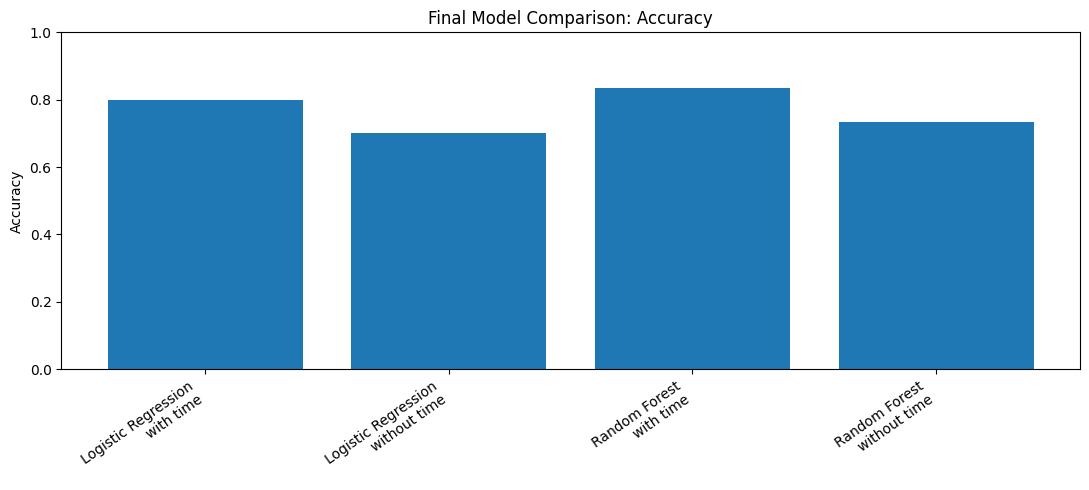

Saved: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures\final_accuracy_comparison.png


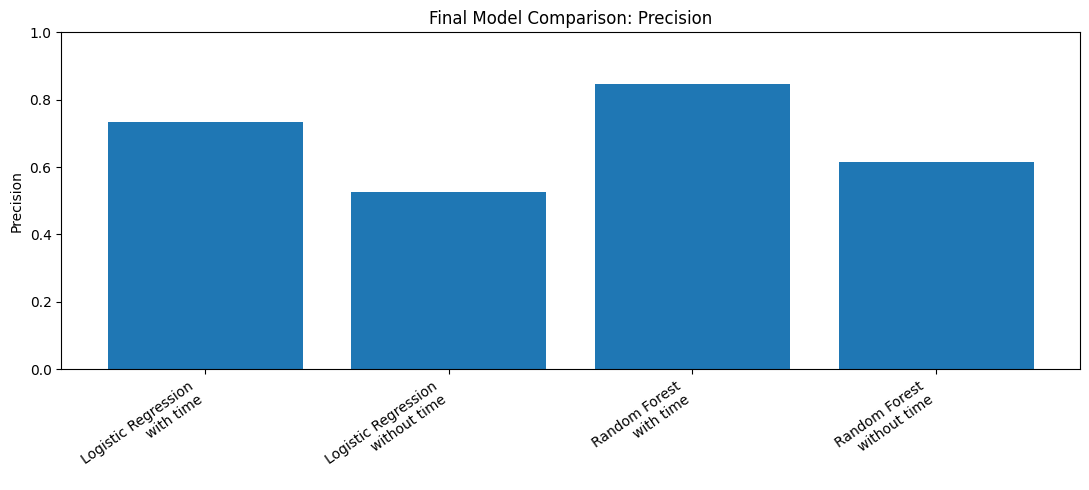

Saved: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures\final_precision_comparison.png


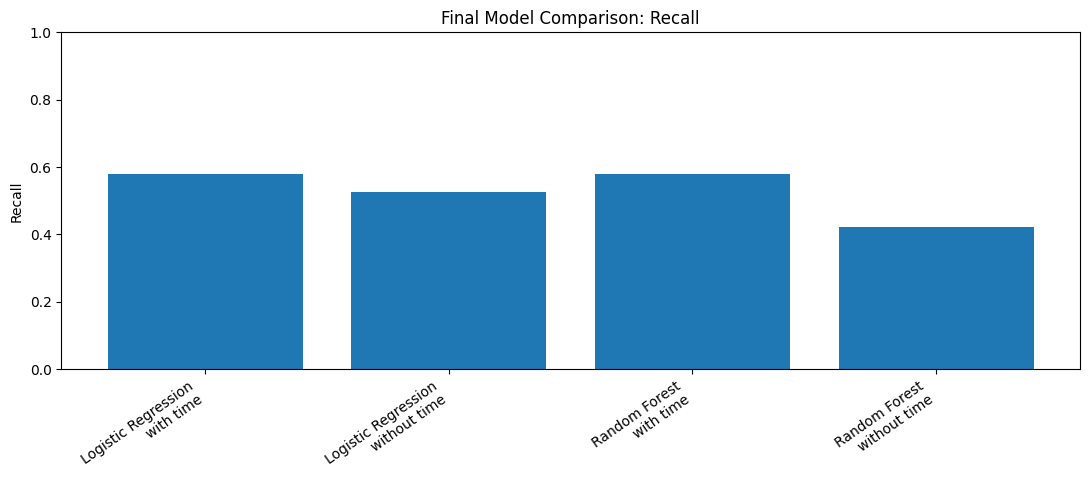

Saved: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures\final_recall_comparison.png


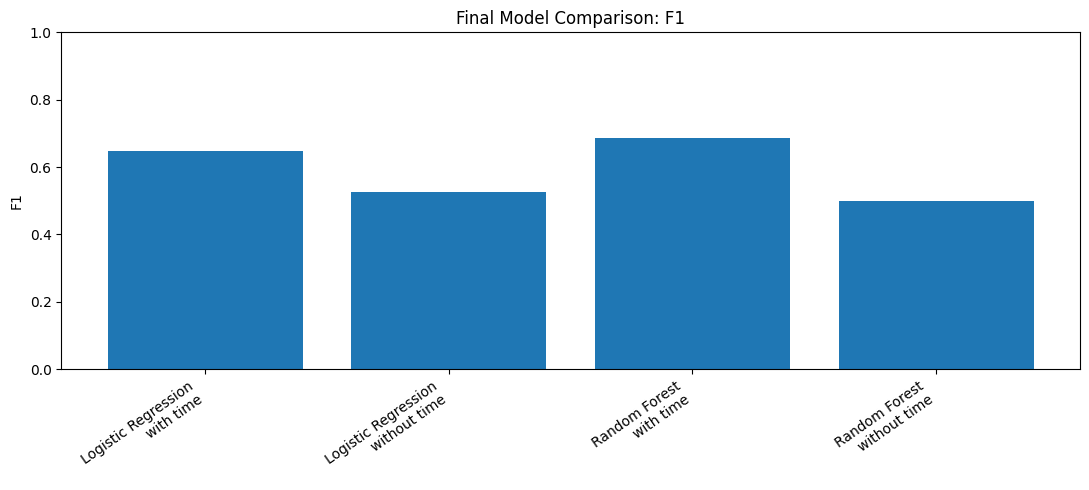

Saved: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures\final_f1_comparison.png


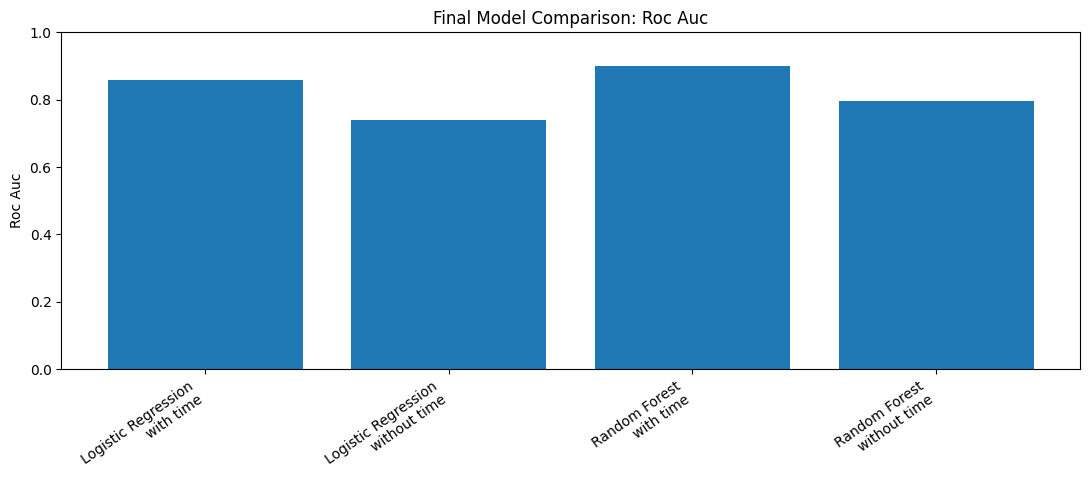

Saved: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures\final_roc_auc_comparison.png


In [10]:
def plot_metric_comparison(results_df: pd.DataFrame, metric: str):
    """Save a bar chart comparing completed model rows for one metric."""
    plot_df = results_df.dropna(subset=[metric]).copy()

    if plot_df.empty:
        print(f"Skipping {metric} plot because there are no completed values yet.")
        return None

    plot_df["label"] = plot_df["model"] + "\n" + plot_df["time_version"].str.replace("_", " ")

    plt.figure(figsize=(11, 5))
    plt.bar(plot_df["label"], plot_df[metric])
    plt.ylim(0, 1)
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Final Model Comparison: {metric.replace('_', ' ').title()}")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"final_{metric}_comparison.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
    return out_path


for metric in metric_cols:
    plot_metric_comparison(final_results, metric)


## Interpretability summary

This section tries to collect the interpretation tables from `04_interpretability.ipynb`.

If the tables are not created yet, the notebook will say which ones are missing. That is okay for now, but before the final paper, I should make sure the interpretability tables and figures exist.


In [11]:
def load_optional_table(possible_file_names, label):
    """Load an optional table from results/tables if it exists."""
    possible_paths = []
    for name in possible_file_names:
        possible_paths.append(TABLES_DIR / name)
        possible_paths.append(METRICS_DIR / name)
        possible_paths.append(PROJECT_ROOT / name)

    found_path = find_existing_file(possible_paths)
    if found_path is None:
        print(f"Missing optional interpretability table: {label}")
        return None

    print(f"Loaded {label} from: {found_path}")
    return pd.read_csv(found_path)


interpretability_files = {
    "Logistic Regression coefficients with time": [
        "logistic_coefficients_with_time.csv",
        "logistic_regression_coefficients_with_time.csv",
    ],
    "Logistic Regression coefficients without time": [
        "logistic_coefficients_without_time.csv",
        "logistic_regression_coefficients_without_time.csv",
    ],
    "Random Forest feature importance with time": [
        "random_forest_feature_importance_with_time.csv",
        "rf_feature_importance_with_time.csv",
    ],
    "Random Forest feature importance without time": [
        "random_forest_feature_importance_without_time.csv",
        "rf_feature_importance_without_time.csv",
    ],
    "Decision Tree feature importance": [
        "decision_tree_feature_importance.csv",
        "decision_tree_interpretation.csv",
    ],
    "Gradient Boosting feature importance": [
        "gradient_boosting_feature_importance.csv",
        "gb_feature_importance.csv",
    ],
}

loaded_interpretability = {}
for label, names in interpretability_files.items():
    loaded_interpretability[label] = load_optional_table(names, label)


Loaded Logistic Regression coefficients with time from: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\logistic_coefficients_with_time.csv
Loaded Logistic Regression coefficients without time from: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\logistic_coefficients_without_time.csv
Loaded Random Forest feature importance with time from: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\random_forest_feature_importance_with_time.csv
Loaded Random Forest feature importance without time from: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\random_forest_feature_importance_without_time.csv
Missing optional interpretability table: Decision Tree feature importance
Missing optional interpretability table: Gradient Boosting feature importance


In [12]:
# Build a simple top-feature summary when the tables are available.

summary_rows = []

for label, table in loaded_interpretability.items():
    if table is None or table.empty:
        continue

    working = table.copy()
    lower_cols = {col.lower().strip(): col for col in working.columns}

    # Try to find a feature column.
    feature_col = None
    for option in ["feature", "variable", "column", "predictor"]:
        if option in lower_cols:
            feature_col = lower_cols[option]
            break

    # Try to find a score column.
    score_col = None
    for option in ["importance", "coefficient", "coef", "abs_coefficient", "mean_importance"]:
        if option in lower_cols:
            score_col = lower_cols[option]
            break

    if feature_col is None:
        continue

    if score_col is not None:
        working["_sort_score"] = pd.to_numeric(working[score_col], errors="coerce").abs()
        working = working.sort_values("_sort_score", ascending=False)

    top_features = working[feature_col].astype(str).head(5).tolist()

    summary_rows.append({
        "source": label,
        "top_features": ", ".join(top_features),
    })

interpretability_summary = pd.DataFrame(summary_rows)
interpretability_summary_path = TABLES_DIR / "final_interpretability_summary.csv"
interpretability_summary.to_csv(interpretability_summary_path, index=False)

print("Saved interpretability summary to:", interpretability_summary_path)
display(interpretability_summary)


Saved interpretability summary to: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\final_interpretability_summary.csv


,source,top_features
0,Logistic Regression coefficients with time,"time, ejection_fraction, serum_creatinine, dia..."
1,Logistic Regression coefficients without time,"serum_creatinine, ejection_fraction, anaemia, ..."
2,Random Forest feature importance with time,"time, serum_creatinine, ejection_fraction, cre..."
3,Random Forest feature importance without time,"serum_creatinine, ejection_fraction, creatinin..."


## Sentences for the final paper

This cell creates draft sentences I can use later in the Results and Discussion sections. I should still edit the wording before putting it into the final NeurIPS paper.


In [13]:
paper_notes = []

if complete_results.empty:
    paper_notes.append("The final model comparison is not complete yet because the metric table still has missing values.")
else:
    best_auc = complete_results.sort_values("roc_auc", ascending=False).iloc[0]
    best_recall = complete_results.sort_values("recall", ascending=False).iloc[0]

    paper_notes.append(
        f"The highest ROC-AUC among the completed models was achieved by {best_auc['model']} "
        f"({best_auc['time_version'].replace('_', ' ')}), with ROC-AUC = {best_auc['roc_auc']:.3f}."
    )
    paper_notes.append(
        f"The highest recall among the completed models was achieved by {best_recall['model']} "
        f"({best_recall['time_version'].replace('_', ' ')}), with recall = {best_recall['recall']:.3f}."
    )

if not time_feature_comparison.empty:
    completed_time = time_feature_comparison.dropna(subset=["difference_with_minus_without"])
    if not completed_time.empty:
        auc_time = completed_time[completed_time["metric"] == "roc_auc"].copy()
        if not auc_time.empty:
            largest_time_effect = auc_time.iloc[auc_time["difference_with_minus_without"].abs().argmax()]
            paper_notes.append(
                f"The largest ROC-AUC difference from including the time feature was for {largest_time_effect['model']}, "
                f"with a with-time minus without-time difference of {largest_time_effect['difference_with_minus_without']:.3f}."
            )

if len(interpretability_summary) > 0:
    paper_notes.append(
        "The interpretability results should be discussed using the saved coefficient and feature-importance tables."
    )

paper_notes_path = TABLES_DIR / "paper_results_notes.txt"
with open(paper_notes_path, "w", encoding="utf-8") as f:
    for note in paper_notes:
        f.write("- " + note + "\n")

print("Saved paper notes to:", paper_notes_path)
print("\nDraft notes:")
for note in paper_notes:
    print("-", note)


Saved paper notes to: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables\paper_results_notes.txt

Draft notes:
- The highest ROC-AUC among the completed models was achieved by Random Forest (with time), with ROC-AUC = 0.899.
- The highest recall among the completed models was achieved by Logistic Regression (with time), with recall = 0.579.
- The largest ROC-AUC difference from including the time feature was for Logistic Regression, with a with-time minus without-time difference of 0.117.
- The interpretability results should be discussed using the saved coefficient and feature-importance tables.


## Final checklist before writing the paper

Before moving to the final paper, I should make sure these are done:

- Salem metrics are saved.
- Tala metrics are saved.
- Final comparison table has 8 completed rows.
- Interpretability tables and figures are saved.
- The README is updated with the final results.
- The GitHub link is public.
- The video link is public.


In [14]:
# Final project status check

status_items = []

status_items.append({
    "item": "Salem metrics file exists",
    "status": (METRICS_DIR / "salem_logistic_randomforest_metrics.csv").exists(),
})

status_items.append({
    "item": "Final model comparison saved",
    "status": (METRICS_DIR / "final_model_comparison.csv").exists(),
})

status_items.append({
    "item": "Final results table saved",
    "status": (TABLES_DIR / "final_results_table.csv").exists(),
})

status_items.append({
    "item": "All metric values filled",
    "status": final_results[metric_cols].notna().all().all(),
})

status_items.append({
    "item": "Interpretability summary saved",
    "status": (TABLES_DIR / "final_interpretability_summary.csv").exists(),
})

status_df = pd.DataFrame(status_items)
display(status_df)

if status_df["status"].all():
    print("Everything in this notebook is complete.")
else:
    print("Some items are still pending. Check the False rows above.")


,item,status
0,Salem metrics file exists,True
1,Final model comparison saved,True
2,Final results table saved,True
3,All metric values filled,False
4,Interpretability summary saved,True


Some items are still pending. Check the False rows above.
